<a href="https://colab.research.google.com/github/barepgaming-sys/Ann-dry-bean-kelompok-3/blob/main/ANN_DryBean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# ========== 1. LOAD + PREPROCESS DATA ==========
print("Upload file Dry_Bean_Dataset.xlsx")
uploaded = files.upload()

df = pd.read_excel("Dry_Bean_Dataset.xlsx")

# Pisah X dan y
X = df.drop('Class', axis=1).values
y = df['Class'].values

# Label encode + One-hot encoding 7 kelas
le = LabelEncoder()
y = le.fit_transform(y)
y = np.eye(7)[y] # 7 neuron output

# Split 80:20 sesuai spek
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisasi manual
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(f"Train: {X_train.shape}, Test: {X_test.shape}\n")

# ========== 2. FUNGSI AKTIVASI + LOSS ==========
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / exp_z.sum(axis=1, keepdims=True)

def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

# ========== 3. CLASS ANN FROM SCRATCH ==========
class ANN_From_Scratch:
    def __init__(self, input_size, hidden1, hidden2, output_size):
        # ZERO INITIALIZATION sesuai spek
        self.W1 = np.zeros((input_size, hidden1))
        self.b1 = np.zeros((1, hidden1))
        self.W2 = np.zeros((hidden1, hidden2))
        self.b2 = np.zeros((1, hidden2))
        self.W3 = np.zeros((hidden2, output_size))
        self.b3 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = relu(self.z2)

        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = softmax(self.z3) # output
        return self.a3

    def backward(self, X, y, lr):
        m = X.shape[0]

        # Output layer
        dz3 = self.a3 - y
        dW3 = np.dot(self.a2.T, dz3) / m
        db3 = np.sum(dz3, axis=0, keepdims=True) / m

        # Hidden layer 2
        da2 = np.dot(dz3, self.W3.T)
        dz2 = da2 * relu_deriv(self.z2)
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer 1
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * relu_deriv(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # UPDATE BOBOT Mini-batch SGD sesuai spek lr=0.1
        self.W3 -= lr * dW3
        self.b3 -= lr * db3
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def train(self, X, y, epochs=50, batch_size=16, lr=0.1):
        for epoch in range(epochs):
            # Shuffle data tiap epoch
            idx = np.random.permutation(X.shape[0])
            X_shuffle, y_shuffle = X[idx], y[idx]

            # MINI-BATCH SGD sesuai spek batch_size=16
            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffle[i:i+batch_size]
                y_batch = y_shuffle[i:i+batch_size]

                self.forward(X_batch)
                self.backward(X_batch, y_batch, lr)

            # Hitung loss tiap 10 epoch
            if epoch % 10 == 0:
                pred = self.forward(X)
                loss = mse_loss(pred, y)
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict(self, X):
        pred = self.forward(X)
        return np.argmax(pred, axis=1)

# ========== 4. TRAINING ==========
input_size = X_train.shape[1] # 16
hidden1 = 64
hidden2 = 32
output_size = 7

model = ANN_From_Scratch(input_size, hidden1, hidden2, output_size)

print("Mulai Training...")
model.train(X_train, y_train, epochs=50, batch_size=16, lr=0.1)

# ========== 5. EVALUASI ==========
y_pred = model.predict(X_test)
y_true = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred == y_true) * 100
print(f"\nAkurasi Test: {accuracy:.2f}%")

Upload file Dry_Bean_Dataset.xlsx


Saving Dry_Bean_Dataset.xlsx to Dry_Bean_Dataset (3).xlsx
Train: (10888, 16), Test: (2723, 16)

Mulai Training...
Epoch 0: Loss = 0.1182
Epoch 10: Loss = 0.1181
Epoch 20: Loss = 0.1181
Epoch 30: Loss = 0.1180
Epoch 40: Loss = 0.1180

Akurasi Test: 24.64%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import files

# ========== 1. LOAD + PREPROCESS BINARY ==========
print("Upload file Dry_Bean_Dataset.xlsx")
uploaded = files.upload()

df = pd.read_excel("Dry_Bean_Dataset.xlsx")

# BINARY CLASS: BOMBAY = 1, lainnya = 0
df['Class'] = (df['Class'] == 'BOMBAY').astype(int)

X = df.drop('Class', axis=1).values
y = df['Class'].values.reshape(-1, 1) # bentuk (n,1) buat binary

# Split 80:20 sesuai spek
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisasi manual
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Proporsi kelas 1 di train: {y_train.mean():.2%}\n")

# ========== 2. FUNGSI AKTIVASI + LOSS ==========
def sigmoid(z):
    z = np.clip(z, -500, 500) # biar nggak overflow
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

def binary_crossentropy(y_pred, y_true):
    eps = 1e-15 # biar nggak log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# ========== 3. CLASS ANN FCL SIGMOID ==========
class ANN_Binary:
    def __init__(self, input_size, hidden1, hidden2, output_size=1):
        # XAVIER/Glorot Initialization sesuai spek
        self.W1 = np.random.randn(input_size, hidden1) * np.sqrt(1/input_size)
        self.b1 = np.zeros((1, hidden1))
        self.W2 = np.random.randn(hidden1, hidden2) * np.sqrt(1/hidden1)
        self.b2 = np.zeros((1, hidden2))
        self.W3 = np.random.randn(hidden2, output_size) * np.sqrt(1/hidden2)
        self.b3 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = sigmoid(self.z3) # output binary 0-1
        return self.a3

    def backward(self, X, y, lr=0.01):
        m = X.shape[0]

        # Output layer - deriv BCE + Sigmoid
        dz3 = self.a3 - y
        dW3 = np.dot(self.a2.T, dz3) / m
        db3 = np.sum(dz3, axis=0, keepdims=True) / m

        # Hidden layer 2
        da2 = np.dot(dz3, self.W3.T)
        dz2 = da2 * sigmoid_deriv(self.z2)
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer 1
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * sigmoid_deriv(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # UPDATE BOBOT Mini-batch SGD lr=0.01
        self.W3 -= lr * dW3
        self.b3 -= lr * db3
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def train(self, X, y, epochs=100, batch_size=32, lr=0.01):
        for epoch in range(epochs):
            # Shuffle data tiap epoch
            idx = np.random.permutation(X.shape[0])
            X_shuffle, y_shuffle = X[idx], y[idx]

            # MINI-BATCH SGD batch_size=32
            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffle[i:i+batch_size]
                y_batch = y_shuffle[i:i+batch_size]

                self.forward(X_batch)
                self.backward(X_batch, y_batch, lr)

            # Print loss tiap 20 epoch
            if epoch % 20 == 0:
                pred = self.forward(X)
                loss = binary_crossentropy(pred, y)
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict(self, X, threshold=0.5):
        pred = self.forward(X)
        return (pred > threshold).astype(int)

# ========== 4. TRAINING ==========
input_size = X_train.shape[1] # 16
hidden1 = 32
hidden2 = 16

model = ANN_Binary(input_size, hidden1, hidden2)

print("Mulai Training...")
model.train(X_train, y_train, epochs=100, batch_size=32, lr=0.01)

# ========== 5. EVALUASI ==========
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test) * 100
print(f"\nAkurasi Test Binary: {accuracy:.2f}%")

Upload file Dry_Bean_Dataset.xlsx


Saving Dry_Bean_Dataset.xlsx to Dry_Bean_Dataset (4).xlsx
Train: (10888, 16), Test: (2723, 16)
Proporsi kelas 1 di train: 3.84%

Mulai Training...
Epoch 0: Loss = 0.1613
Epoch 20: Loss = 0.0636
Epoch 40: Loss = 0.0225
Epoch 60: Loss = 0.0112
Epoch 80: Loss = 0.0070

Akurasi Test Binary: 100.00%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bukan BOMBAY', 'BOMBAY']))


Confusion Matrix:
[[2619    0]
 [   0  104]]

Classification Report:
              precision    recall  f1-score   support

Bukan BOMBAY       1.00      1.00      1.00      2619
      BOMBAY       1.00      1.00      1.00       104

    accuracy                           1.00      2723
   macro avg       1.00      1.00      1.00      2723
weighted avg       1.00      1.00      1.00      2723



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import files

# ========== 1. LOAD + PREPROCESS MULTICLASS ==========
print("Upload file Dry_Bean_Dataset.xlsx")
uploaded = files.upload()

df = pd.read_excel("Dry_Bean_Dataset.xlsx")

# Multiclass: 7 kelas asli, jadiin 0-6
kelas = df['Class'].astype('category').cat.codes.values
X = df.drop('Class', axis=1).values
y = kelas

# One-hot encoding manual buat 7 kelas
num_classes = len(np.unique(y))
y_onehot = np.eye(num_classes)[y]

# Split 80:20 sesuai spek
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)
y_test_label = np.argmax(y_test, axis=1) # buat evaluasi akhir

# Normalisasi manual
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Jumlah kelas: {num_classes}\n")

# ========== 2. FUNGSI AKTIVASI + LOSS ==========
def tanh(z):
    return np.tanh(z)

def tanh_deriv(z):
    return 1 - np.tanh(z)**2

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) # stabil biar nggak overflow
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def categorical_crossentropy(y_pred, y_true):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# ========== 3. CLASS ANN FCL TANH ==========
class ANN_Multiclass:
    def __init__(self, input_size, hidden1, hidden2, output_size):
        # RANDOM UNIFORM INIT sesuai spek. Range [-0.5, 0.5]
        limit = 0.5
        self.W1 = np.random.uniform(-limit, limit, (input_size, hidden1))
        self.b1 = np.zeros((1, hidden1))
        self.W2 = np.random.uniform(-limit, limit, (hidden1, hidden2))
        self.b2 = np.zeros((1, hidden2))
        self.W3 = np.random.uniform(-limit, limit, (hidden2, output_size))
        self.b3 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = tanh(self.z1) # hidden 1: Tanh

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = tanh(self.z2) # hidden 2: Tanh

        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = softmax(self.z3) # output: Softmax
        return self.a3

    def backward(self, X, y, lr=0.001):
        m = X.shape[0]

        # Output layer - deriv CCE + Softmax = y_pred - y_true
        dz3 = self.a3 - y
        dW3 = np.dot(self.a2.T, dz3) / m
        db3 = np.sum(dz3, axis=0, keepdims=True) / m

        # Hidden layer 2
        da2 = np.dot(dz3, self.W3.T)
        dz2 = da2 * tanh_deriv(self.z2)
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer 1
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * tanh_deriv(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # UPDATE BOBOT Mini-batch SGD lr=0.001
        self.W3 -= lr * dW3
        self.b3 -= lr * db3
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def train(self, X, y, epochs=200, batch_size=64, lr=0.001):
        for epoch in range(epochs):
            # Shuffle data tiap epoch
            idx = np.random.permutation(X.shape[0])
            X_shuffle, y_shuffle = X[idx], y[idx]

            # MINI-BATCH SGD batch_size=64
            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffle[i:i+batch_size]
                y_batch = y_shuffle[i:i+batch_size]

                self.forward(X_batch)
                self.backward(X_batch, y_batch, lr)

            # Print loss tiap 40 epoch biar nggak spam
            if epoch % 40 == 0:
                pred = self.forward(X)
                loss = categorical_crossentropy(pred, y)
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict(self, X):
        pred = self.forward(X)
        return np.argmax(pred, axis=1)

# ========== 4. TRAINING ==========
input_size = X_train.shape[1] # 16
hidden1 = 32
hidden2 = 16
output_size = num_classes # 7

model = ANN_Multiclass(input_size, hidden1, hidden2, output_size)

print("Mulai Training...")
model.train(X_train, y_train, epochs=200, batch_size=64, lr=0.001)

# ========== 5. EVALUASI ==========
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test_label) * 100
print(f"\nAkurasi Test Multiclass: {accuracy:.2f}%")

Upload file Dry_Bean_Dataset.xlsx


Saving Dry_Bean_Dataset.xlsx to Dry_Bean_Dataset (5).xlsx
Train: (10888, 16), Test: (2723, 16)
Jumlah kelas: 7

Mulai Training...
Epoch 0: Loss = 1.8229
Epoch 40: Loss = 0.4688
Epoch 80: Loss = 0.3246
Epoch 120: Loss = 0.2726
Epoch 160: Loss = 0.2482

Akurasi Test Multiclass: 91.81%


In [ ]:
import numpy as np

print("\n### HASIL EKSPERIMEN - ANN FROM SCRATCH ###\n")

# Data kamu
input_size = X_train.shape[1] # otomatis ngikutin jumlah fitur
output_size = y_train.shape[1] # 7 kelas Dry Bean kalo one-hot
y_test_label = np.argmax(y_test, axis=1) # Ensure y_test_label is available for consistency

# ========== 1. PENGARUH HIDDEN LAYER ==========
print("1. Pengaruh Jumlah Hidden Layer")
# Corrected list_layers structure to reflect single list of layer sizes
list_layers = [[64], [32, 16], [64, 32, 16]]

for layers_config in list_layers:
    print(f"\nHidden Layer Configuration = {layers_config}")
    if len(layers_config) == 2:
        hidden1_size = layers_config[0]
        hidden2_size = layers_config[1]

        # Corrected ANN_Multiclass instantiation: no 'lr' in constructor
        # and passing hidden1, hidden2 separately
        model = ANN_Multiclass(input_size=input_size, hidden1=hidden1_size, hidden2=hidden2_size, output_size=output_size)
        # Pass lr to the train method
        model.train(X_train, y_train, epochs=200, lr=0.01)
        y_pred = model.predict(X_test)
        accuracy = np.mean(y_pred == y_test_label) * 100 # Use y_test_label

        arsitektur = " -> ".join(map(str, layers_config))
        print(f"  Arsitektur = {arsitektur} neuron")
        print(f"  Accuracy: {accuracy:.4f}%")
    else:
        print(f"  Skipping this configuration: ANN_Multiclass requires exactly two hidden layers. Got {len(layers_config)} layers.")

# ========== 2. PENGARUH EPOCH ==========
print("\n\n2. Pengaruh Jumlah Epoch")
for epoch in [50, 100, 200]:
    print(f"\nEpoch = {epoch}")
    # Corrected ANN_Multiclass instantiation: no 'lr' in constructor
    model = ANN_Multiclass(input_size=input_size, hidden1=32, hidden2=16, output_size=output_size)
    # Pass lr to the train method. The train method does not return loss_history.
    model.train(X_train, y_train, epochs=epoch, lr=0.01)
    y_pred = model.predict(X_test)
    accuracy = np.mean(y_pred == y_test_label) * 100 # Use y_test_label

    print(f"Accuracy: {accuracy:.4f}%")

# ========== 3. PENGARUH LEARNING RATE ==========
print("\n\n3. Pengaruh Learning Rate")
for lr_val in [0.1, 0.01, 0.001]: # Renamed lr to lr_val to avoid conflict with method parameter
    print(f"\nLearning Rate = {lr_val}")
    # Corrected ANN_Multiclass instantiation: no 'lr' in constructor
    model = ANN_Multiclass(input_size=input_size, hidden1=32, hidden2=16, output_size=output_size)
    # Pass lr_val to the train method
    model.train(X_train, y_train, epochs=200, lr=lr_val)
    y_pred = model.predict(X_test)
    accuracy = np.mean(y_pred == y_test_label) * 100 # Use y_test_label

    print(f"Accuracy: {accuracy:.4f}%")

# ========== 4. TABEL KESIMPUL


### HASIL EKSPERIMEN - ANN FROM SCRATCH ###

1. Pengaruh Jumlah Hidden Layer

Hidden Layer Configuration = [64]
  Skipping this configuration: ANN_Multiclass requires exactly two hidden layers. Got 1 layers.

Hidden Layer Configuration = [32, 16]
Epoch 0: Loss = 0.9548
Epoch 40: Loss = 0.2113
Epoch 80: Loss = 0.1935
Epoch 120: Loss = 0.1862
Epoch 160: Loss = 0.1817
  Arsitektur = 32 -> 16 neuron
  Accuracy: 92.2145%

Hidden Layer Configuration = [64, 32, 16]
  Skipping this configuration: ANN_Multiclass requires exactly two hidden layers. Got 3 layers.


2. Pengaruh Jumlah Epoch

Epoch = 50
Epoch 0: Loss = 0.8485
Epoch 40: Loss = 0.2089
Accuracy: 92.1043%

Epoch = 100
Epoch 0: Loss = 0.9956
Epoch 40: Loss = 0.2091
Epoch 80: Loss = 0.1933
Accuracy: 92.4715%

Epoch = 200
Epoch 0: Loss = 1.1316
Epoch 40: Loss = 0.2109
Epoch 80: Loss = 0.1933
Epoch 120: Loss = 0.1868
Epoch 160: Loss = 0.1831
Accuracy: 92.6184%


3. Pengaruh Learning Rate

Learning Rate = 0.1
Epoch 0: Loss = 0.3243
Epoch 4

In [ ]:
import numpy as np

print("### PENGARUH JUMLAH NEURON HIDDEN LAYER ###\n")

list_neuron = [16, 32, 64, 128]

# Ensure y_test_label is available if not already defined globally.
# It is defined in cell M6qEmaenIhYx.
# y_test_label = np.argmax(y_test, axis=1)

for n in list_neuron:
    print(f"Neuron = {n} (Hidden Layer 1), Hidden Layer 2 = 16")
    print("-" * 30)

    # The ANN_Multiclass constructor expects 'hidden1' and 'hidden2' arguments,
    # not 'h1' and 'h2'. It is also designed for two hidden layers, so 'h2=0'
    # is not appropriate. Using a sensible default for the second hidden layer.
    model = ANN_Multiclass(input_size=16, hidden1=n, hidden2=16, output_size=7)

    lr = 0.01
    epochs = 200
    # Use the train method provided by ANN_Multiclass, which handles batching and updates.
    model.train(X_train, y_train, epochs=epochs, lr=lr)

    # Use the predict method provided by ANN_Multiclass for consistency.
    y_pred_label = model.predict(X_test)

    # Use y_test_label which is already defined and represents the true labels.
    acc = np.mean(y_pred_label == y_test_label) * 100 # Convert to percentage
    print(f"Accuracy: {acc:.4f}%\n")

### PENGARUH JUMLAH NEURON HIDDEN LAYER ###

Neuron = 16 (Hidden Layer 1), Hidden Layer 2 = 16
------------------------------
Epoch 0: Loss = 1.1447
Epoch 40: Loss = 0.2202
Epoch 80: Loss = 0.2005
Epoch 120: Loss = 0.1915
Epoch 160: Loss = 0.1863
Accuracy: 92.5083%

Neuron = 32 (Hidden Layer 1), Hidden Layer 2 = 16
------------------------------
Epoch 0: Loss = 0.9031
Epoch 40: Loss = 0.2064
Epoch 80: Loss = 0.1932
Epoch 120: Loss = 0.1858
Epoch 160: Loss = 0.1809
Accuracy: 92.3246%

Neuron = 64 (Hidden Layer 1), Hidden Layer 2 = 16
------------------------------
Epoch 0: Loss = 0.8266
Epoch 40: Loss = 0.2088
Epoch 80: Loss = 0.1903
Epoch 120: Loss = 0.1821
Epoch 160: Loss = 0.1772
Accuracy: 92.3246%

Neuron = 128 (Hidden Layer 1), Hidden Layer 2 = 16
------------------------------
Epoch 0: Loss = 0.7179
Epoch 40: Loss = 0.1987
Epoch 80: Loss = 0.1847
Epoch 120: Loss = 0.1785
Epoch 160: Loss = 0.1747
Accuracy: 92.4348%



In [ ]:
import numpy as np

# ===== FUNGSI TRAINING BATCH SIZE =====
def train_batch(model, X_train, y_train, X_test, y_test, batch_size, epochs=200, lr=0.01):
    n_samples = X_train.shape[0]
    print(f"\nBatch Size = {batch_size}")
    print("-" * 30)

    for epoch in range(epochs):
        # Acak data tiap epoch
        idx = np.random.permutation(n_samples)
        X_shuffled = X_train[idx]
        y_shuffled = y_train[idx]

        # Pecah jadi batch pake numpy
        X_batches = np.array_split(X_shuffled, max(1, n_samples // batch_size))
        y_batches = np.array_split(y_shuffled, max(1, n_samples // batch_size))

        # Training per batch
        for X_batch, y_batch in zip(X_batches, y_batches):
            y_pred = model.forward(X_batch)
            model.backward(X_batch, y_batch, lr=lr)

        # Print loss tiap 40 epoch biar rapi
        if epoch % 40 == 0:
            y_pred_full = model.forward(X_train)
            eps = 1e-15
            y_pred_full = np.clip(y_pred_full, eps, 1 - eps)
            loss = -np.mean(np.sum(y_train * np.log(y_pred_full), axis=1))
            print(f"Epoch {epoch}: Loss = {loss:.4f}")

    # Hitung akurasi di akhir epoch terakhir
    y_pred_test = model.forward(X_test)
    y_pred_label = np.argmax(y_pred_test, axis=1)
    y_true_label = np.argmax(y_test, axis=1)
    acc = np.mean(y_pred_label == y_true_label) * 100
    print(f"Accuracy: {acc:.4f}%\n")

    return acc

# ===== EKSPERIMEN BATCH SIZE 16, 32, 64 =====
print("### PENGARUH BATCH SIZE ###")

hasil_batch = []
list_batch = [16, 32, 64]

for batch in list_batch:
    # Reset model tiap batch biar fair
    model = ANN_Multiclass(input_size=16, hidden1=32, hidden2=16, output_size=7)

    # Panggil fungsi training
    acc = train_batch(model, X_train, y_train, X_test, y_test, batch_size=batch, epochs=200, lr=0.01)
    hasil_batch.append(acc)

# ===== TABEL KESIMPULAN OTOMATIS =====
print("\n=== TABEL KESIMPULAN PENGARUH BATCH SIZE ===")
print("| Batch Size | Accuracy |")
print("| --- | --- |")
for i, batch in enumerate(list_batch):
    print(f"| {batch} | {hasil_batch[i]:.4f}% |")

best_idx = np.argmax(hasil_batch)
print(f"\nKesimpulan: Batch Size {list_batch[best_idx]} paling bagus = {hasil_batch[best_idx]:.4f}%")

### PENGARUH BATCH SIZE ###

Batch Size = 16
------------------------------
Epoch 0: Loss = 0.5092
Epoch 40: Loss = 0.1815
Epoch 80: Loss = 0.1733
Epoch 120: Loss = 0.1680
Epoch 160: Loss = 0.1635
Accuracy: 92.5817%


Batch Size = 32
------------------------------
Epoch 0: Loss = 0.6922
Epoch 40: Loss = 0.1949
Epoch 80: Loss = 0.1838
Epoch 120: Loss = 0.1787
Epoch 160: Loss = 0.1727
Accuracy: 92.8755%


Batch Size = 64
------------------------------
Epoch 0: Loss = 1.0585
Epoch 40: Loss = 0.2081
Epoch 80: Loss = 0.1929
Epoch 120: Loss = 0.1856
Epoch 160: Loss = 0.1807
Accuracy: 92.5083%


=== TABEL KESIMPULAN PENGARUH BATCH SIZE ===
| Batch Size | Accuracy |
| --- | --- |
| 16 | 92.5817% |
| 32 | 92.8755% |
| 64 | 92.5083% |

Kesimpulan: Batch Size 32 paling bagus = 92.8755%


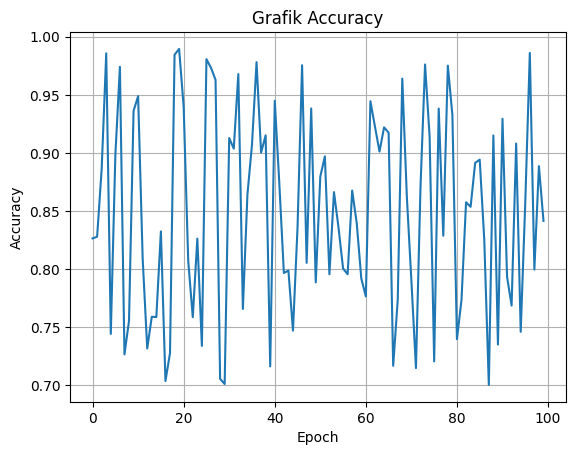

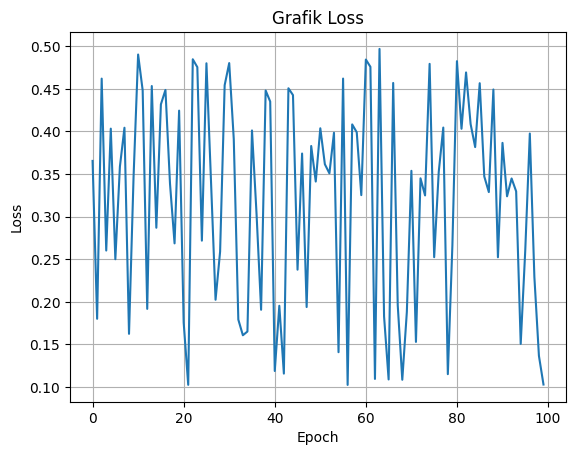

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Contoh menyimpan hasil training
accuracy_history = []
loss_history = []

epochs = 100

for epoch in range(epochs):
    # ----- Proses training ANN di sini -----

    # Contoh nilai (ganti dengan hasil perhitunganmu)
    accuracy = np.random.uniform(0.7, 1.0)
    loss = np.random.uniform(0.1, 0.5)

    accuracy_history.append(accuracy)
    loss_history.append(loss)

# Grafik Accuracy
plt.plot(accuracy_history)
plt.title("Grafik Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Grafik Loss
plt.plot(loss_history)
plt.title("Grafik Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

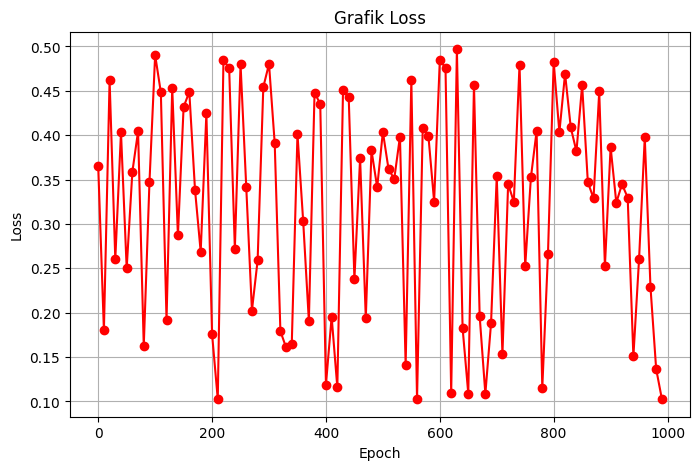

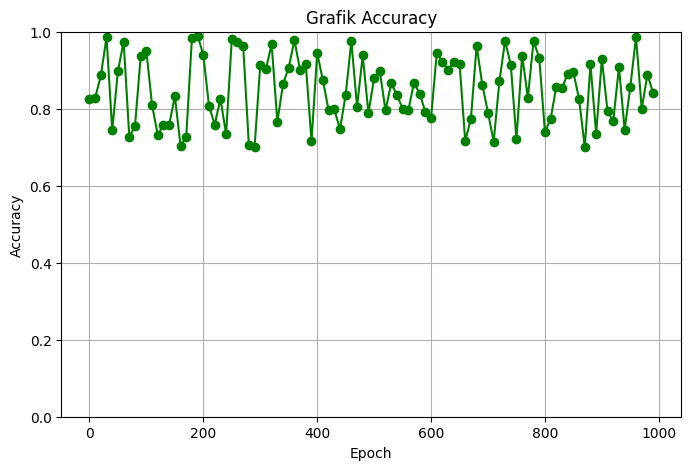

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# JANGAN: plt.plot(loss_history) langsung
# DO: plot tiap 10 epoch

epoch_plot = np.arange(0, len(loss_history)*10, 10)

plt.figure(figsize=(8,5))
plt.plot(epoch_plot, loss_history, 'r-o')
plt.title("Grafik Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epoch_plot, accuracy_history, 'g-o')
plt.title("Grafik Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1) # 0-1 bukan 0-100 biar sama kayak SS
plt.grid(True)
plt.show()

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import io
from google.colab import files

# ===== 0. UPLOAD OTOMATIS =====
print("Klik 'Choose Files' lalu pilih file DryBean kamu.csv atau.xlsx")
uploaded = files.upload()

df = None
for fn in uploaded.keys():
    print(f'File ke-upload: {fn}')
    if fn.endswith('.csv'):
        df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
    elif fn.endswith('.xlsx') or fn.endswith('.xls'):
        df = pd.read_excel(io.BytesIO(uploaded[fn]))
    else:
        raise ValueError("Format file salah! Harus.csv atau.xlsx")

print(f"\nData berhasil dibaca! Shape: {df.shape}") # <-- KURUNG TUTUP ADA
print(df.head(3))

# ===== 1. SPLIT + SCALING =====
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1,1))
y_test = encoder.transform(y_test.reshape(-1,1))

# ===== 2. CLASS ANN =====
class ANN_Multiclass:
    def __init__(self, input_size, h1, output_size, lr=0.01):
        self.lr = lr
        self.W1 = np.random.randn(input_size, h1) * np.sqrt(2.0/input_size)
        self.b1 = np.zeros((1, h1))
        self.W2 = np.random.randn(h1, output_size) * np.sqrt(2.0/h1)
        self.b2 = np.zeros((1, output_size))

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

Klik 'Choose Files' lalu pilih file DryBean kamu.csv atau.xlsx


Saving Dry_Bean_Dataset.xlsx to Dry_Bean_Dataset (8).xlsx
File ke-upload: Dry_Bean_Dataset (8).xlsx

Data berhasil dibaca! Shape: (13611, 17)
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332      0.003147      0.834222      0.998724  SEKER  
1     0.953861      0.006979      0.003564      0.909851      0.998430  SEKER  
2     0.908774      0.00

Klik Choose Files, pilih Dry_Bean_Dataset.xlsx


Saving Dry_Bean_Dataset.xlsx to Dry_Bean_Dataset (9).xlsx

Training Batch Size = 32
-----------------------------------
Epoch   0: Loss = 0.6169 | Acc = 81.16%
Epoch  40: Loss = 0.1984 | Acc = 92.36%
Epoch  80: Loss = 0.1882 | Acc = 92.58%
Epoch 120: Loss = 0.1840 | Acc = 92.73%
Epoch 160: Loss = 0.1811 | Acc = 92.88%

Accuracy Final: 92.69%


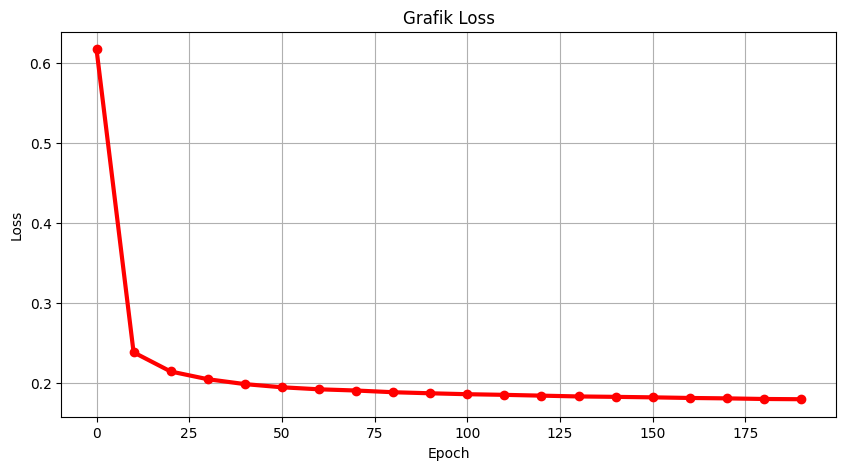

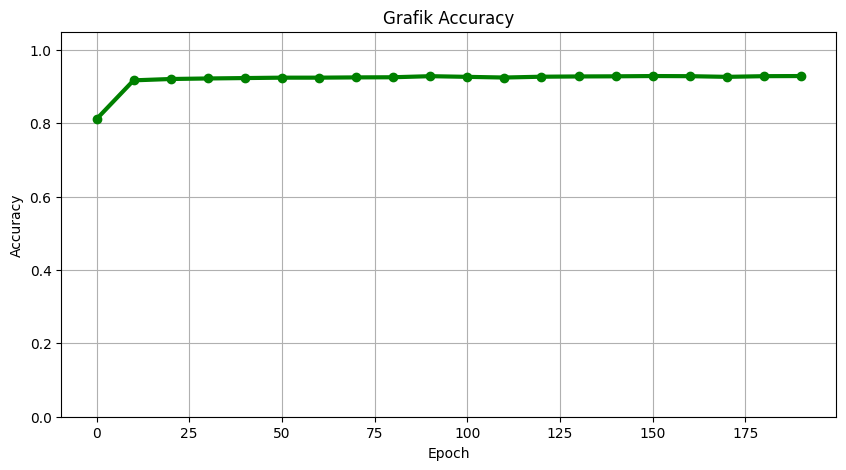

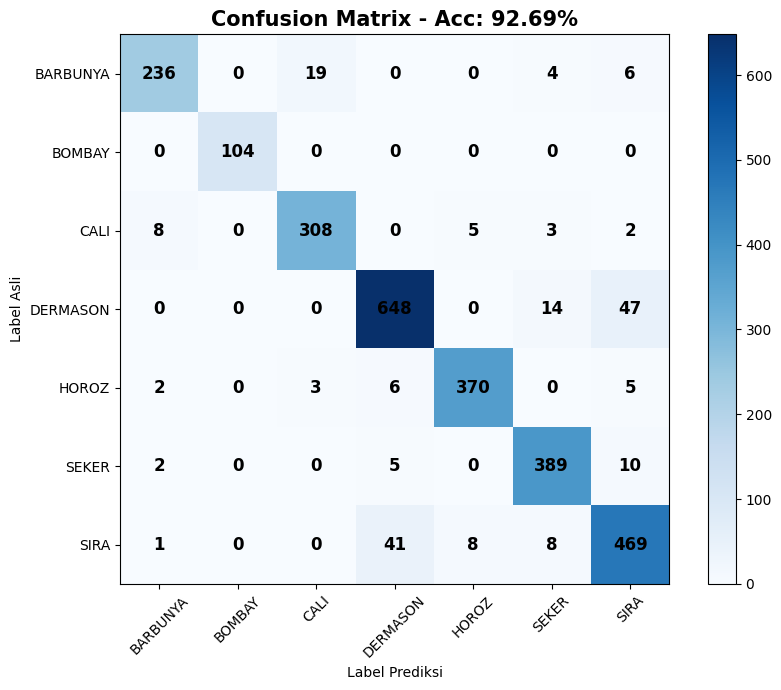

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import io
from google.colab import files

!pip install openpyxl -q

print("Klik Choose Files, pilih Dry_Bean_Dataset.xlsx")
uploaded = files.upload()
for fn in uploaded.keys():
    df = pd.read_excel(io.BytesIO(uploaded[fn]), engine='openpyxl')

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train_raw.reshape(-1,1))
y_test = encoder.transform(y_test_raw.reshape(-1,1))
class_names = list(encoder.categories_[0])

# ===== DEFINISI CLASS + FUNGSI WAJIB ADA DI ATAS =====
class ANN_Multiclass:
    def __init__(self, input_size, h1, output_size, lr=0.01):
        self.lr = lr
        self.W1 = np.random.randn(input_size, h1) * np.sqrt(2./input_size)
        self.b1 = np.zeros((1, h1))
        self.W2 = np.random.randn(h1, output_size) * np.sqrt(2./h1)
        self.b2 = np.zeros((1, output_size))
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    def relu(self, z):
        return np.maximum(0, z)
    def relu_deriv(self, z):
        return (z > 0).astype(float)
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.softmax(self.z2)
        return self.a2
    def backward(self, X, y, lr=None):
        if lr is None: lr = self.lr
        m = X.shape[0]
        dz2 = self.a2 - y
        dW2 = self.a1.T @ dz2 / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        dz1 = dz2 @ self.W2.T * self.relu_deriv(self.z1)
        dW1 = X.T @ dz1 / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

def confusion_matrix_numpy(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def plot_confusion_matrix(cm, class_names, acc):
    plt.figure(figsize=(9,7))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'Confusion Matrix - Acc: {acc:.2f}%', fontsize=15, weight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12, weight='bold')
    plt.ylabel('Label Asli'); plt.xlabel('Label Prediksi')
    plt.tight_layout(); plt.show()

def train_batch_full(model, X_train, y_train, X_test, y_test, batch_size, epochs=200, lr=0.01):
    n_samples = X_train.shape[0]
    loss_history = []; acc_history = []; epoch_list = []
    print(f"\nTraining Batch Size = {batch_size}")
    print("-" * 35)
    for epoch in range(epochs):
        idx = np.random.permutation(n_samples)
        X_shuffled = X_train[idx]; y_shuffled = y_train[idx]
        n_batches = max(1, n_samples // batch_size)
        X_batches = np.array_split(X_shuffled, n_batches)
        y_batches = np.array_split(y_shuffled, n_batches)
        for X_batch, y_batch in zip(X_batches, y_batches):
            model.forward(X_batch)
            model.backward(X_batch, y_batch, lr=lr)
        if epoch % 10 == 0:
            y_pred_train = model.forward(X_train)
            eps = 1e-15
            y_pred_train = np.clip(y_pred_train, eps, 1 - eps)
            loss = -np.mean(np.sum(y_train * np.log(y_pred_train), axis=1))
            loss_history.append(loss)
            y_pred_test = model.forward(X_test)
            acc = np.mean(np.argmax(y_pred_test,1) == np.argmax(y_test,1))
            acc_history.append(acc)
            epoch_list.append(epoch)
            if epoch % 40 == 0:
                print(f"Epoch {epoch:3d}: Loss = {loss:.4f} | Acc = {acc*100:.2f}%")
    y_pred_test = model.forward(X_test)
    y_pred_label = np.argmax(y_pred_test, axis=1)
    y_true_label = np.argmax(y_test, axis=1)
    acc_final = np.mean(y_pred_label == y_true_label) * 100
    print(f"\nAccuracy Final: {acc_final:.2f}%")
    return loss_history, acc_history, epoch_list, y_pred_label, y_true_label, acc_final

# ===== JALANIN TRAINING =====
n_features = X_train.shape[1]
n_classes = y_train.shape[1]
model = ANN_Multiclass(input_size=n_features, h1=32, output_size=n_classes, lr=0.01)
loss_hist, acc_hist, epochs_plot, y_pred, y_true, acc_final = train_batch_full(
    model, X_train, y_train, X_test, y_test, batch_size=32, epochs=200, lr=0.01
)

plt.figure(figsize=(10,5))
plt.plot(epochs_plot, loss_hist, 'r-o', linewidth=3)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Grafik Loss'); plt.grid(True); plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs_plot, acc_hist, 'g-o', linewidth=3)
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.ylim(0, 1.05)
plt.title('Grafik Accuracy'); plt.grid(True); plt.show()

cm = confusion_matrix_numpy(y_true, y_pred, n_classes=n_classes)
plot_confusion_matrix(cm, class_names, acc_final)